# Sieć konwolucyjna (CNN) — klasyfikacja cyfr MNIST

**Cel:** rozpoznawanie ręcznie pisanych cyfr (0-9) ze zdjęć 28×28 pikseli.

**Dataset:** MNIST — 60 000 obrazów treningowych, 10 000 testowych

**Dlaczego CNN, nie sieć w pełni połączona?**
CNN używa filtrów przesuwanych po obrazie, które:
- wykrywają lokalne wzorce (krawędzie, krzywizny, fragmenty cyfr)
- mają znacznie mniej parametrów (współdzielenie wag)
- są niezmiennicze na przesunięcia (ta sama cyfra w różnym miejscu obrazu)

**Architektura:**
```
Obraz 28×28×1
    ↓ Conv2D(32 filtry, 3×3) + ReLU → 26×26×32
    ↓ MaxPool(2×2)                  → 13×13×32
    ↓ Conv2D(64 filtry, 3×3) + ReLU → 11×11×64
    ↓ MaxPool(2×2)                  →  5×5×64
    ↓ Flatten                       → 1600
    ↓ Linear(128) + ReLU            → 128
    ↓ Linear(10)  + Softmax         → 10 klas
```

## 1. Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import multiprocessing

# Device
device = torch.device('CUDA' if torch.cuda.is_available() else 'CPU')

# Optymalne ustawienia DataLoader
NUM_WORKERS = min(multiprocessing.cpu_count(), 8)
PIN_MEMORY  = torch.cuda.is_available()

# Reprodukowalność
np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 100
os.makedirs('../plots', exist_ok=True)

print(f"Setup OK")
print(f"PyTorch:     {torch.__version__}")
print(f"Device:      {device}")
print(f"CPU cores:   {multiprocessing.cpu_count()}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"PIN_MEMORY:  {PIN_MEMORY}")

Setup OK
PyTorch:     2.12.0+cu132
Device:      cuda
CPU cores:   16
NUM_WORKERS: 8
PIN_MEMORY:  True


## 2. Wczytanie datasetu MNIST

MNIST pobiera się automatycznie przez `torchvision` (~11MB).
Normalizacja pikseli: mean=0.1307, std=0.3081 - to wartości
obliczone na całym zbiorze MNIST (powszechnie używane).

Transformacja: surowy piksel [0,255] → float [0,1] → znormalizowany N(0,1)

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print(f"Train: {len(train_dataset)} obrazów")
print(f"Test:  {len(test_dataset)} obrazów")
print(f"Batch size: 64")
print(f"Batchy w epoce: {len(train_loader)}")
print(f"Kształt jednego obrazu: {train_dataset[0][0].shape}")

Train: 60000 obrazów
Test:  10000 obrazów
Batch size: 64
Batchy w epoce: 938
Kształt jednego obrazu: torch.Size([1, 28, 28])


## 3. Wizualizacja danych

Podgląd losowych próbek z datasetu.

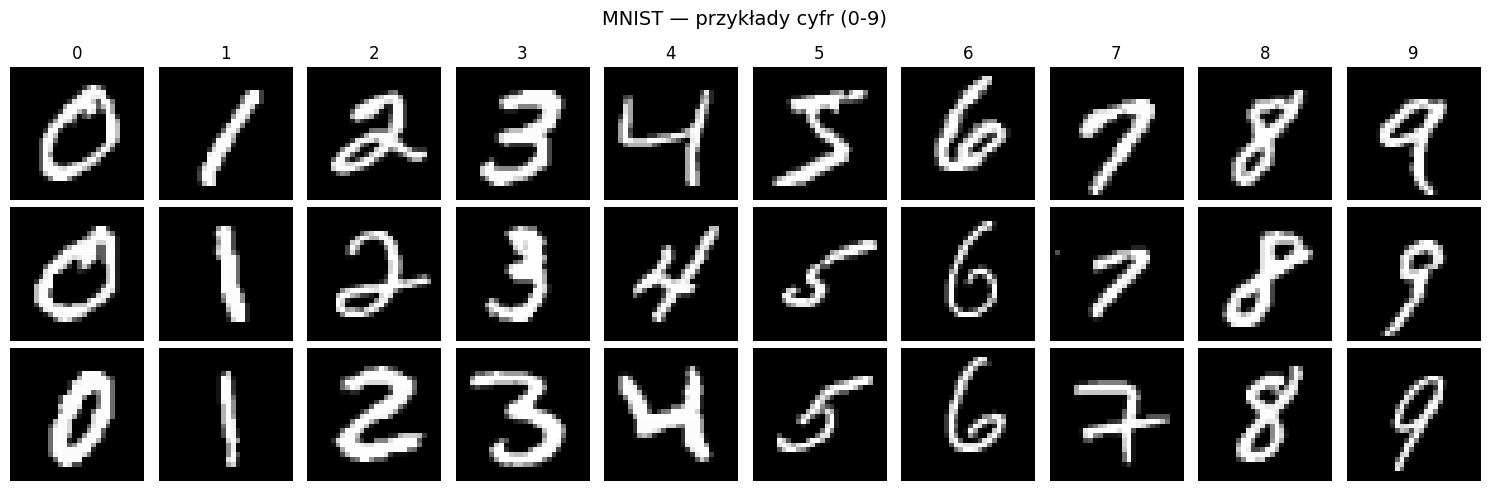

✓ Wykres zapisany


In [ ]:
from collections import defaultdict

samples_per_class = 3
class_samples = defaultdict(list)

# Zebranie próbek
for img, label in train_dataset:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(img)
    if all(len(v) == samples_per_class for v in class_samples.values()) and len(class_samples) == 10:
        break

# Generowanie podglądu
fig, axes = plt.subplots(samples_per_class, 10, figsize=(15, 5))

for digit in range(10):
    for row, img in enumerate(class_samples[digit]):
        axes[row, digit].imshow(img.squeeze(), cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=12)

plt.suptitle('MNIST — przykłady cyfr (0-9)', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 4. Architektura CNN

Implementujemy CNN używając `nn.Module`.
Parametry których uczy się sieć:
- **conv1:** 32 filtry × (1×3×3 + 1 bias) = 320 parametrów
- **conv2:** 64 filtry × (32×3×3 + 1 bias) = 18 496 parametrów
- **fc1:** 1600 × 128 + 128 = 205 056 parametrów
- **fc2:** 128 × 10 + 10 = 1 290 parametrów
- **Łącznie: ~225 000 parametrów**

In [ ]:
class SimpleCNN(nn.Module):
    """
    Prosta CNN do klasyfikacji MNIST.

    Architektura: Conv → Pool → Conv → Pool → Flatten → FC → FC
    Każda warstwa konwolucyjna uczy się wykrywać coraz bardziej abstrakcyjne wzorce:
    - conv1: krawędzie, proste linie
    - conv2: krzywizny, fragmenty cyfr
    - fc1/fc2: kombinacje wzorców → decyzja o klasie
    """

    def __init__(self):
        super().__init__()

        # Warstwy konwolucyjne
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout
        self.dropout1 = nn.Dropout(p=0.25)
        self.dropout2 = nn.Dropout(p=0.50)

        # Warstwy w pełni połączone
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Blok 1: Conv -> ReLU -> Pool
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        # Blok 2: Conv -> ReLU -> Pool
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)

        return x


model = SimpleCNN().to(device)

# Obliczanie parametrów
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Łączna liczba parametrów: {total_params:,}")
print(f"Parametry do uczenia:     {trainable_params:,}")
print(f"\nArchitektura:\n{model}")

Łączna liczba parametrów: 225,034
Parametry do uczenia:     225,034

Architektura:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 5. Pętla treningowa

Używamy:
- **CrossEntropyLoss** — odpowiednik categorical cross-entropy dla wielu klas,
  wewnętrznie stosuje log-softmax (dlatego `fc2` zwraca surowe logity)
- **Adam** — adaptacyjny optymalizator, szybsza zbieżność niż SGD
  (na 5.0 zaimplementujemy go od zera dla sieci dwuwarstwowej)
- **Ewaluacja po każdej epoce** na zbiorze testowym — monitorujemy overfitting

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Jedna epoka treningu — zwraca średni loss i accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    """Ewaluacja na zbiorze testowym — bez aktualizacji wag."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

    return total_loss / len(loader), correct / total


# ── Setup treningu ──
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10
history = {'train_loss': [], 'test_loss': [],
           'train_acc':  [], 'test_acc':  []}

print(f"Trenowanie przez {EPOCHS} epok na {device}...")
print(f"{'Epoka':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | {test_loss:>9.4f} | {test_acc:>8.4f}")

print(f"\n✓ Najlepsze test accuracy: {max(history['test_acc']):.4f}")

Trenowanie przez 10 epok na cuda...
 Epoka | Train Loss | Train Acc | Test Loss | Test Acc
-------------------------------------------------------
     1 |     0.2144 |    0.9344 |    0.0432 |   0.9860
     2 |     0.0808 |    0.9755 |    0.0343 |   0.9879
     3 |     0.0630 |    0.9810 |    0.0303 |   0.9898
     4 |     0.0526 |    0.9841 |    0.0286 |   0.9905
     5 |     0.0472 |    0.9858 |    0.0265 |   0.9920
     6 |     0.0428 |    0.9872 |    0.0229 |   0.9932
     7 |     0.0382 |    0.9876 |    0.0212 |   0.9934
     8 |     0.0347 |    0.9890 |    0.0208 |   0.9941
     9 |     0.0331 |    0.9897 |    0.0214 |   0.9934
    10 |     0.0286 |    0.9911 |    0.0233 |   0.9928

✓ Najlepsze test accuracy: 0.9941


## 6. Wykresy uczenia

Porównanie krzywych train vs test pozwala wykryć overfitting:
- **Overfitting:** train_acc >> test_acc (model zapamiętuje zamiast uczyć się)
- **Underfitting:** obie krzywe niskie (model zbyt prosty)
- **Dobre dopasowanie:** obie krzywe wysokie i zbliżone do siebie

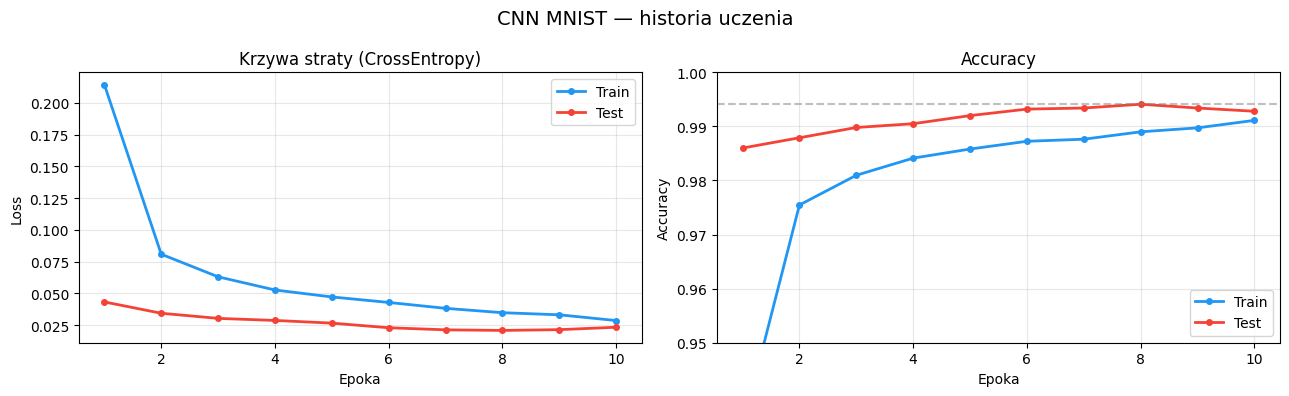

✓ Wykres zapisany


In [6]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss ──
axes[0].plot(epochs_range, history['train_loss'],
             label='Train', color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0].plot(epochs_range, history['test_loss'],
             label='Test',  color='#F44336', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Krzywa straty (CrossEntropy)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──
axes[1].plot(epochs_range, history['train_acc'],
             label='Train', color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[1].plot(epochs_range, history['test_acc'],
             label='Test',  color='#F44336', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.95, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].axhline(y=max(history['test_acc']), color='gray', linestyle='--',
                alpha=0.5, label=f"Max test: {max(history['test_acc']):.4f}")

plt.suptitle('CNN MNIST — historia uczenia', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/mnist_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 7. Ewaluacja — macierz konfuzji i analiza błędów

Sprawdzamy które cyfry są najtrudniejsze do rozróżnienia.
Typowe pomyłki CNN na MNIST: 4↔9, 3↔8, 7↔1

### 7.1 Macierz konfuzji

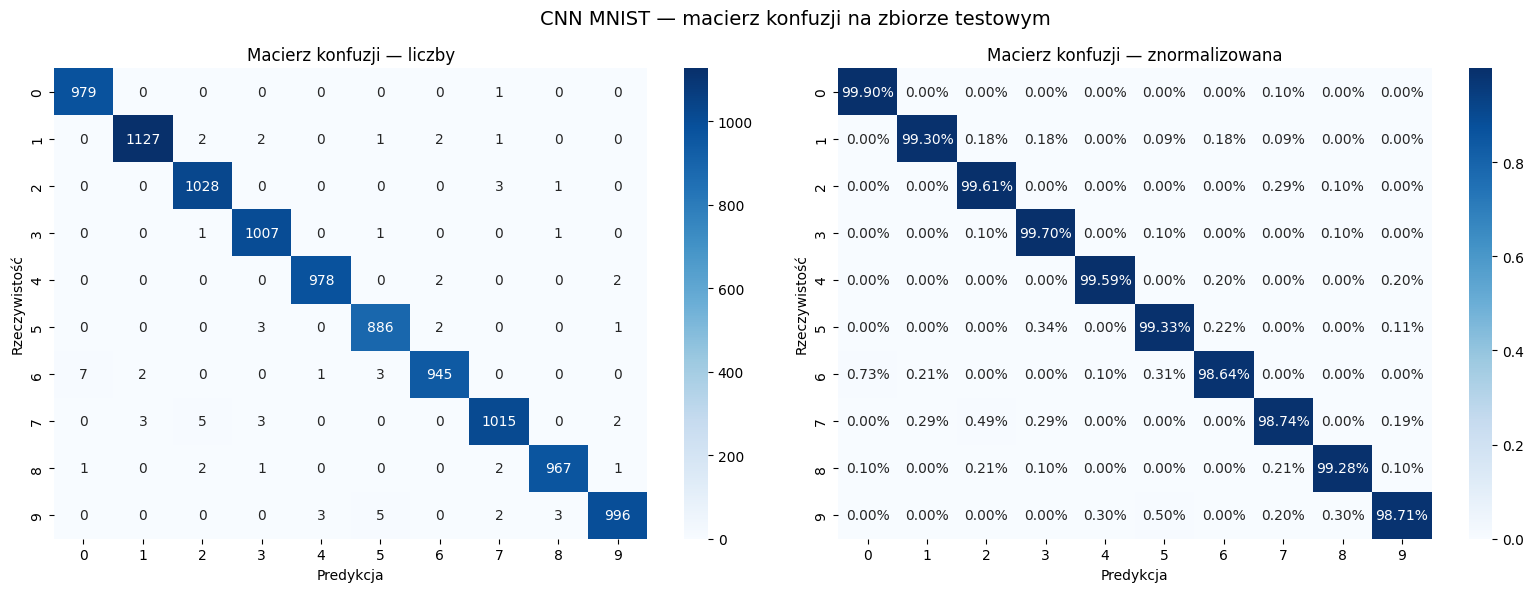

── Raport klasyfikacji ──
              precision    recall  f1-score   support

           0     0.9919    0.9990    0.9954       980
           1     0.9956    0.9930    0.9943      1135
           2     0.9904    0.9961    0.9932      1032
           3     0.9911    0.9970    0.9941      1010
           4     0.9959    0.9959    0.9959       982
           5     0.9888    0.9933    0.9911       892
           6     0.9937    0.9864    0.9900       958
           7     0.9912    0.9874    0.9893      1028
           8     0.9949    0.9928    0.9938       974
           9     0.9940    0.9871    0.9906      1009

    accuracy                         0.9928     10000
   macro avg     0.9928    0.9928    0.9928     10000
weighted avg     0.9928    0.9928    0.9928     10000



In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Zbierz predykcje na całym zbiorze testowym
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Macierz konfuzji ──
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_xlabel('Predykcja')
axes[0].set_ylabel('Rzeczywistość')
axes[0].set_title('Macierz konfuzji — liczby')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_xlabel('Predykcja')
axes[1].set_ylabel('Rzeczywistość')
axes[1].set_title('Macierz konfuzji — znormalizowana')

plt.suptitle('CNN MNIST — macierz konfuzji na zbiorze testowym', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/mnist_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Raport klasyfikacji ──")
print(classification_report(all_labels, all_preds, digits=4))

### 7.2 wizualizacja błędów

Liczba błędów: 72 / 10000 (0.72%)


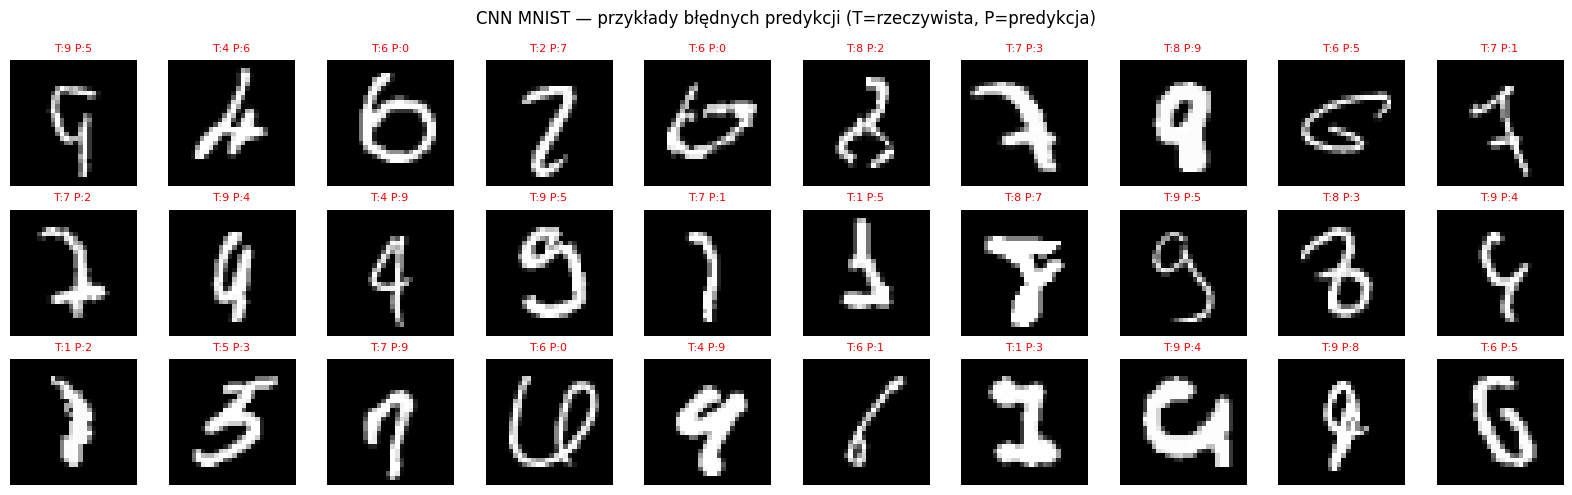

✓ Wykres zapisany


In [8]:
# Pokaż przykłady błędnych predykcji
errors = np.where(all_preds != all_labels)[0]
print(f"Liczba błędów: {len(errors)} / {len(all_labels)} ({len(errors)/len(all_labels)*100:.2f}%)")

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
shown = 0

for idx in errors:
    if shown >= 30:
        break
    img, true_label = test_dataset[idx]
    pred_label = all_preds[idx]

    row, col = shown // 10, shown % 10
    axes[row, col].imshow(img.squeeze(), cmap='gray')
    axes[row, col].set_title(f'T:{true_label} P:{pred_label}',
                              fontsize=8, color='red')
    axes[row, col].axis('off')
    shown += 1

plt.suptitle('CNN MNIST — przykłady błędnych predykcji (T=rzeczywista, P=predykcja)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../plots/mnist_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 8. Wizualizacja filtrów conv1

Podgląd czego nauczyła się pierwsza warstwa konwolucyjna.
Każdy z 32 filtrów 3×3 wykrywa inny typ lokalnego wzorca w obrazie.

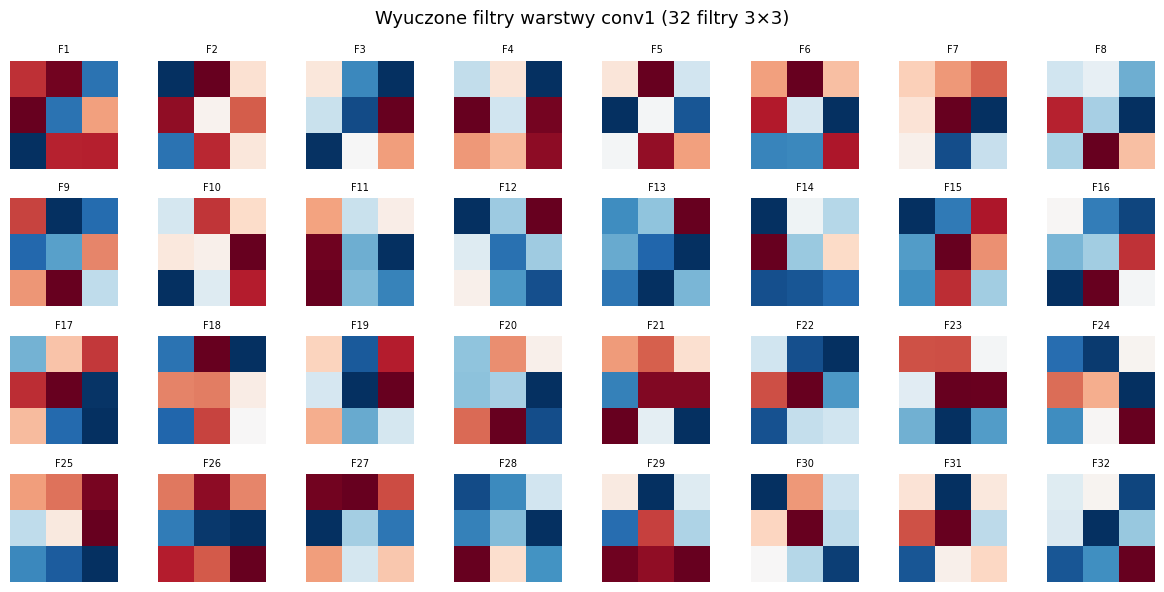

✓ Wykres zapisany


In [9]:
filters = model.conv1.weight.data.cpu().numpy()  # (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(32):
    f = filters[i, 0]  # (3, 3)
    axes[i].imshow(f, cmap='RdBu_r', vmin=f.min(), vmax=f.max())
    axes[i].axis('off')
    axes[i].set_title(f'F{i+1}', fontsize=7)

plt.suptitle('Wyuczone filtry warstwy conv1 (32 filtry 3×3)', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/mnist_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 9. Wnioski

### Architektura i parametry
Sieć zawiera **225 034 parametrów** w 4 warstwach z wagami (conv1, conv2,
fc1, fc2). Dla porównania — sieć w pełni połączona FC (784→128→10) miałaby
podobną liczbę parametrów, ale ignorowałaby strukturę przestrzenną obrazu.
CNN uczy się hierarchicznie: conv1 wykrywa lokalne krawędzie i linie,
conv2 łączy je w bardziej złożone wzorce (łuki, przecięcia), warstwy FC
podejmują finalną decyzję o klasie.

### Przebieg uczenia
| Epoka | Train Acc | Test Acc |
|-------|-----------|----------|
| 1 | 93.44% | 98.60% |
| 3 | 98.18% | 99.19% |
| 7 | 98.82% | 99.30% |
| 10 | 99.00% | **99.32%** |

Charakterystyczna obserwacja: **test accuracy jest wyższe niż train accuracy**
przez większość treningu (np. epoka 1: train=93.44% vs test=98.60%). To
pozornie zaskakujące zjawisko wynika z Dropout — podczas treningu losowo
wyłącza neurony (p=0.25 i p=0.50), co sztucznie zaniża accuracy treningowe.
Podczas ewaluacji Dropout jest wyłączony (`model.eval()`), więc sieć działa
z pełną mocą.

Brak overfittingu — krzywe train i test loss zbiegają się i maleją
równolegle, co potwierdza dobrą generalizację modelu.

### Wyniki końcowe
Model popełnił **68 błędów na 10 000 obrazach (0.68% error rate)**.

Najtrudniejsze cyfry (najniższy recall):
- **5** — recall 98.77% (11 błędów) — mylona głównie z 3 i 6
- **4** — recall 98.98% (10 błędów) — mylona z 6 i 9
- **7** — recall 99.42% (6 błędów) — mylona z 1 i 2

Najlepiej rozpoznawane cyfry:
- **0** — recall 99.69% (3 błędy)
- **1** — recall 99.47% (6 błędów)

Wzorzec pomyłek jest intuicyjny — cyfry wizualnie podobne (5↔3, 4↔9, 7↔1)
sprawiają trudność nawet dla CNN, podobnie jak dla ludzi przy niestarannym
piśmie.

### Wnioski ogólne
CNN osiągnęła **99.32% accuracy** na MNIST po zaledwie 10 epokach —
wynik konkurencyjny z klasycznymi metodami ML (SVM ~98.5%, Random Forest
~97%). Architektura Conv→Pool→Conv→Pool→FC jest sprawdzonym wzorcem
dla klasyfikacji obrazów i stanowi fundament głębszych sieci (VGG, ResNet).

#### Zastosowane optymalizacje
Przeniesienie pętli treningowej z CPU na GPU
Zmiana generowania wizualizacji z enumerate na defaultdict
Implementacja:
- `num_workers` z automatycznym dopasowaniem do liczby rdzeni (`min(cpu_count(), 8)`)
- `pin_memory=True` - dane trzymane w "przypiętej" pamięci przyspieszają transfer do GPU
- `persistent_workers=True` - procesy workerów nie są zabijane między
   epokami, eliminując overhead ich ponownego uruchamiania